PENGELOMPOKKAN PEFORMA AKADEMIK SISWA BERDASARKAN NILAI MATEMATIKA, MEMBACA, DAN MENULIS

IMPORT LIBRARY

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score

Tahap 1 Data Understanding

In [120]:
df = pd.read_csv("data_performa_siswa.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1051 entries, 0 to 1050
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Gender                       1051 non-null   object
 1   parental level of education  1051 non-null   object
 2   lunch                        1051 non-null   object
 3   test preparation course      1051 non-null   object
 4   math score                   1051 non-null   int64 
 5   reading score                1051 non-null   int64 
 6   writing score                1051 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 57.6+ KB


,math score,reading score,writing score
count,1051.000000,1051.000000,1051.000000
mean,66.805899,70.143673,69.019981
std,15.272646,15.003470,15.541912
min,0.000000,17.000000,10.000000
25%,57.000000,60.000000,58.000000
50%,67.000000,71.000000,70.000000
75%,78.000000,81.000000,80.000000
max,100.000000,100.000000,100.000000


Tahap 2 Data Preprocessing

In [121]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


,0
Gender,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [122]:
features_score = ['math score', 'reading score', 'writing score']

print("\n--- Penanganan Outlier (Tanpa Menghapus Data) ---")

for col in features_score:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung jumlah outlier
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"Outlier pada {col}: {outliers_count} nilai akan disesuaikan")

print(f"\nTotal data setelah preprocessing: {df.shape[0]} baris ")


--- Penanganan Outlier (Tanpa Menghapus Data) ---
Outlier pada math score: 7 nilai akan disesuaikan
Outlier pada reading score: 6 nilai akan disesuaikan
Outlier pada writing score: 5 nilai akan disesuaikan

Total data setelah preprocessing: 1051 baris 


In [123]:
# --- 2.3 Encoding Data Kategorikal (Label Encoding) ---
# Teknik ini mengubah teks menjadi angka tanpa menambah kolom baru
le = LabelEncoder()
categorical_cols = ['Gender', 'parental level of education', 'lunch', 'test preparation course']

# Kita timpa kolom asli dengan versi angka
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("--- Hasil Encoding ---")
display(df.head())

--- Hasil Encoding ---


,Gender,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,2,1,1,75,90,85
1,1,1,1,1,70,85,80
2,0,1,1,1,85,85,85
3,0,2,1,1,79,90,90
4,0,1,1,1,85,100,100


In [124]:
# --- 2.4 Standarisasi Data ---
# Kita siapkan data untuk model clustering (hanya kolom skor)
features_score = ['math score', 'reading score', 'writing score']
scaler = StandardScaler()

# Melakukan scaling
scaled_values = scaler.fit_transform(df[features_score])

# Membuat dataframe hasil scaling untuk digunakan di tahap berikutnya
df_final_scaled = pd.DataFrame(scaled_values, columns=features_score)

print("\n--- Data Setelah Standarisasi (Siap untuk Model) ---")
display(df_final_scaled.head())


--- Data Setelah Standarisasi (Siap untuk Model) ---


,math score,reading score,writing score
0,0.536777,1.324079,1.028678
1,0.209238,0.990664,0.706814
2,1.191854,0.990664,1.028678
3,0.798808,1.324079,1.350542
4,1.191854,1.990909,1.994270


Tahap 3 Exploratory Data AnalysisEDA

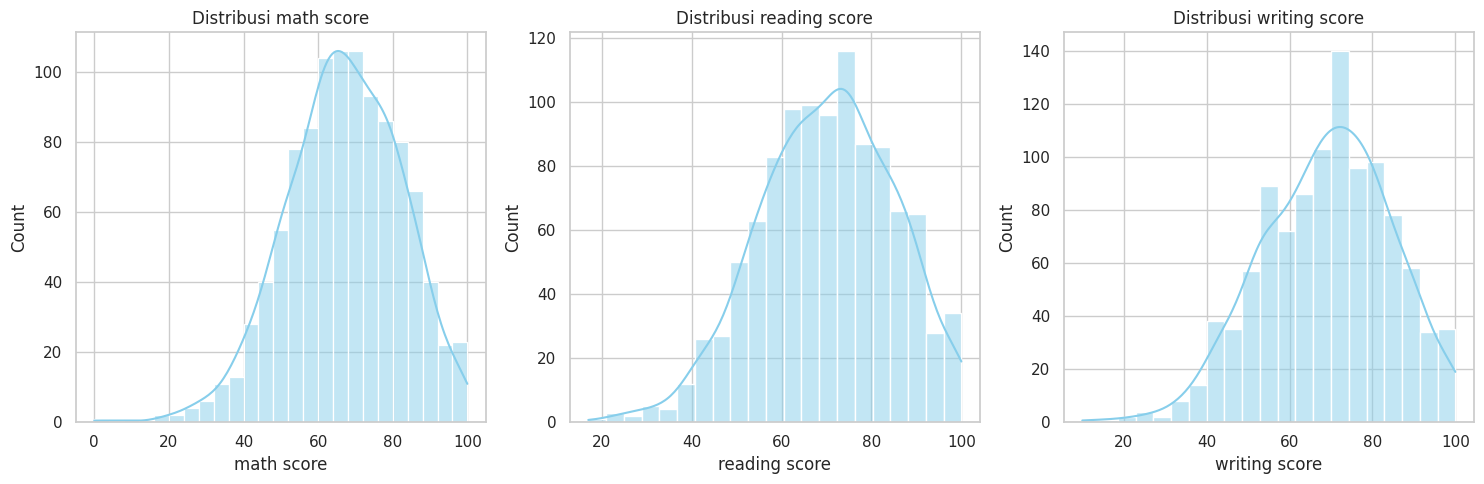

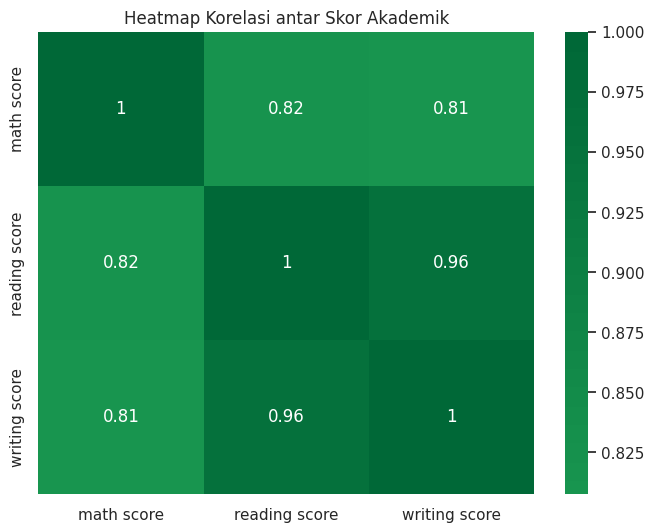

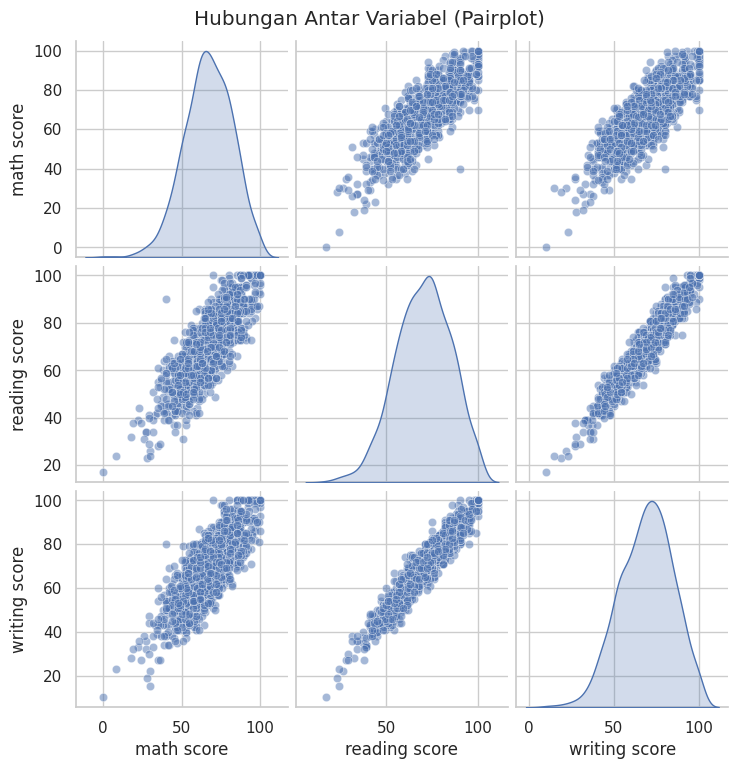

In [125]:
# Mengatur tema visualisasi
sns.set(style="whitegrid")

# --- 3.1 Visualisasi Distribusi Skor (Setelah Cleaning) ---
plt.figure(figsize=(15, 5))
features = ['math score', 'reading score', 'writing score']

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

# --- 3.2 Analisis Korelasi (Heatmap) ---
# Ini penting untuk melihat apakah nilai math, reading, dan writing saling berhubungan
plt.figure(figsize=(8, 6))
corr_matrix = df[features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Heatmap Korelasi antar Skor Akademik')
plt.show()

# --- 3.3 Pairplot (Melihat Sebaran Data untuk Clustering) ---
# Grafik ini menunjukkan bagaimana data "berkumpul" jika dilihat dari dua sudut pandang
sns.pairplot(df[features], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Hubungan Antar Variabel (Pairplot)', y=1.02)
plt.show()

Tahap 4 Data Splitting

In [126]:
# Data
X = df_final_scaled

# Variasi split
X_train_70, X_test_30 = train_test_split(X, test_size=0.30, random_state=42)
X_train_80, X_test_20 = train_test_split(X, test_size=0.20, random_state=42)
X_train_90, X_test_10 = train_test_split(X, test_size=0.10, random_state=42)

print("--- Hasil Data Splitting ---")
print(f"70:30 -> Train: {len(X_train_70)}, Test: {len(X_test_30)}")
print(f"80:20 -> Train: {len(X_train_80)}, Test: {len(X_test_20)}")
print(f"90:10 -> Train: {len(X_train_90)}, Test: {len(X_test_10)}")

--- Hasil Data Splitting ---
70:30 -> Train: 735, Test: 316
80:20 -> Train: 840, Test: 211
90:10 -> Train: 945, Test: 106


Tahap 5 Model Building

In [127]:
# =========================
# SPLIT 70:30
# =========================

# K-Means
kmeans_70 = KMeans(n_clusters=3, random_state=42)
labels_kmeans_70 = kmeans_70.fit_predict(X_train_70)

# Agglomerative
agglo_70 = AgglomerativeClustering(n_clusters=3)
labels_agglo_70 = agglo_70.fit_predict(X_train_70)

# GMM
gmm_70 = GaussianMixture(n_components=3, random_state=42)
labels_gmm_70 = gmm_70.fit_predict(X_train_70)


# =========================
# SPLIT 80:20
# =========================

kmeans_80 = KMeans(n_clusters=3, random_state=42)
labels_kmeans_80 = kmeans_80.fit_predict(X_train_80)

agglo_80 = AgglomerativeClustering(n_clusters=3)
labels_agglo_80 = agglo_80.fit_predict(X_train_80)

gmm_80 = GaussianMixture(n_components=3, random_state=42)
labels_gmm_80 = gmm_80.fit_predict(X_train_80)


# =========================
# SPLIT 90:10
# =========================

kmeans_90 = KMeans(n_clusters=3, random_state=42)
labels_kmeans_90 = kmeans_90.fit_predict(X_train_90)

agglo_90 = AgglomerativeClustering(n_clusters=3)
labels_agglo_90 = agglo_90.fit_predict(X_train_90)

gmm_90 = GaussianMixture(n_components=3, random_state=42)
labels_gmm_90 = gmm_90.fit_predict(X_train_90)


Tahap 6 Hyperparameter Tuning

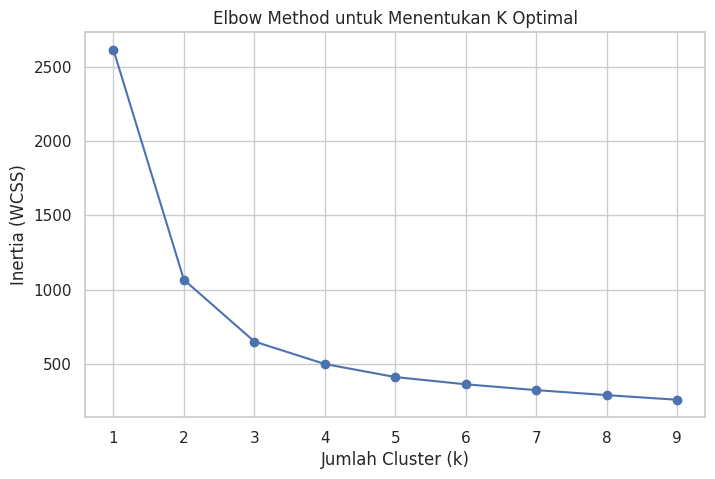

In [128]:
# Skenario pembagian data yang dipilih (misal 80:20)
data_elbow = X_train_80
inertia_values = []
k_range = range(1, 10) # Rentang k diperluas agar siku terlihat

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_elbow)
    inertia_values.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.show()

In [129]:
# Daftar dataset yang akan diuji
datasets = {
    "Split 70:30": X_train_70,
    "Split 80:20": X_train_80,
    "Split 90:10": X_train_90
}

# Daftar nilai k dari 2 sampai 4
k_values = [2, 3, 4]

print("=== TAHAP HYPERPARAMETER TUNING (Analisis Nilai K) ===")

for ds_name, data in datasets.items():
    print(f"\n" + "="*33)
    print(f" DATASET: {ds_name}")
    print("="*33)

    for k in k_values:
        print(f"\n[ Uji Jumlah Cluster k = {k} ]")

        # 1. K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_km = kmeans.fit_predict(data)
        dbi_km = davies_bouldin_score(data, labels_km)

        # 2. Agglomerative (linkage ward)
        agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels_agglo = agglo.fit_predict(data)
        dbi_agglo = davies_bouldin_score(data, labels_agglo)

        # 3. GMM (spherical)
        gmm = GaussianMixture(n_components=k, covariance_type='spherical', random_state=42)
        labels_gmm = gmm.fit_predict(data)
        dbi_gmm = davies_bouldin_score(data, labels_gmm)

        # Tampilkan Hasil Per k
        print(f"  > K-Means       : DBI = {dbi_km:.4f}")
        print(f"  > Agglomerative : DBI = {dbi_agglo:.4f}")
        print(f"  > GMM           : DBI = {dbi_gmm:.4f}")


=== TAHAP HYPERPARAMETER TUNING (Analisis Nilai K) ===

 DATASET: Split 70:30

[ Uji Jumlah Cluster k = 2 ]
  > K-Means       : DBI = 0.7319
  > Agglomerative : DBI = 0.7388
  > GMM           : DBI = 0.7328

[ Uji Jumlah Cluster k = 3 ]
  > K-Means       : DBI = 0.7674
  > Agglomerative : DBI = 0.8594
  > GMM           : DBI = 0.7745

[ Uji Jumlah Cluster k = 4 ]
  > K-Means       : DBI = 0.8075
  > Agglomerative : DBI = 0.8810
  > GMM           : DBI = 0.7946

 DATASET: Split 80:20

[ Uji Jumlah Cluster k = 2 ]
  > K-Means       : DBI = 0.7289
  > Agglomerative : DBI = 0.7130
  > GMM           : DBI = 0.7304

[ Uji Jumlah Cluster k = 3 ]
  > K-Means       : DBI = 0.7602
  > Agglomerative : DBI = 0.8054
  > GMM           : DBI = 0.7657

[ Uji Jumlah Cluster k = 4 ]
  > K-Means       : DBI = 0.8152
  > Agglomerative : DBI = 0.8266
  > GMM           : DBI = 0.7944

 DATASET: Split 90:10

[ Uji Jumlah Cluster k = 2 ]
  > K-Means       : DBI = 0.7255
  > Agglomerative : DBI = 0.7045
  > GM

Tahap 7 Evaluasi

In [130]:
print("=== Model Final (Split 70:30) ===")

# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_train_70)
dbi_kmeans = davies_bouldin_score(X_train_70, labels_kmeans)

# Agglomerative (k=2, ward)
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo = agglo.fit_predict(X_train_70)
dbi_agglo = davies_bouldin_score(X_train_70, labels_agglo)

# GMM (k=2, spherical)
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
labels_gmm = gmm.fit_predict(X_train_70)
dbi_gmm = davies_bouldin_score(X_train_70, labels_gmm)

# Output
print(f"K-Means        :k={gmm.n_components} : DBI = {dbi_kmeans:.4f}")
print(f"Agglomerative  :k={gmm.n_components} : DBI = {dbi_agglo:.4f}")
print(f"GMM            :k={gmm.n_components} : DBI = {dbi_gmm:.4f}")

print("\n=== Model Final (Split 80:20) ===")

# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_train_80)
dbi_kmeans = davies_bouldin_score(X_train_80, labels_kmeans)

# Agglomerative (k=2, ward)
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo = agglo.fit_predict(X_train_80)
dbi_agglo = davies_bouldin_score(X_train_80, labels_agglo)

# GMM (k=2, spherical)
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
labels_gmm = gmm.fit_predict(X_train_80)
dbi_gmm = davies_bouldin_score(X_train_80, labels_gmm)

# Output
print(f"K-Means        :k={gmm.n_components} : DBI = {dbi_kmeans:.4f}")
print(f"Agglomerative  :k={gmm.n_components} : DBI = {dbi_agglo:.4f}")
print(f"GMM            :k={gmm.n_components} : DBI = {dbi_gmm:.4f}")

print("\n=== Model Final (Split 90:10) ===")

# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_train_90)
dbi_kmeans = davies_bouldin_score(X_train_90, labels_kmeans)

# Agglomerative (k=2, ward)
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo = agglo.fit_predict(X_train_90)
dbi_agglo = davies_bouldin_score(X_train_90, labels_agglo)

# GMM (k=2, spherical)
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
labels_gmm = gmm.fit_predict(X_train_90)
dbi_gmm = davies_bouldin_score(X_train_90, labels_gmm)

# Output
print(f"K-Means        :k={gmm.n_components} : DBI = {dbi_kmeans:.4f}")
print(f"Agglomerative  :k={gmm.n_components} : DBI = {dbi_agglo:.4f}")
print(f"GMM            :k={gmm.n_components} : DBI = {dbi_gmm:.4f}")

=== Model Final (Split 70:30) ===
K-Means        :k=2 : DBI = 0.7319
Agglomerative  :k=2 : DBI = 0.7388
GMM            :k=2 : DBI = 0.7328

=== Model Final (Split 80:20) ===
K-Means        :k=2 : DBI = 0.7289
Agglomerative  :k=2 : DBI = 0.7130
GMM            :k=2 : DBI = 0.7304

=== Model Final (Split 90:10) ===
K-Means        :k=2 : DBI = 0.7250
Agglomerative  :k=2 : DBI = 0.7045
GMM            :k=2 : DBI = 0.7264


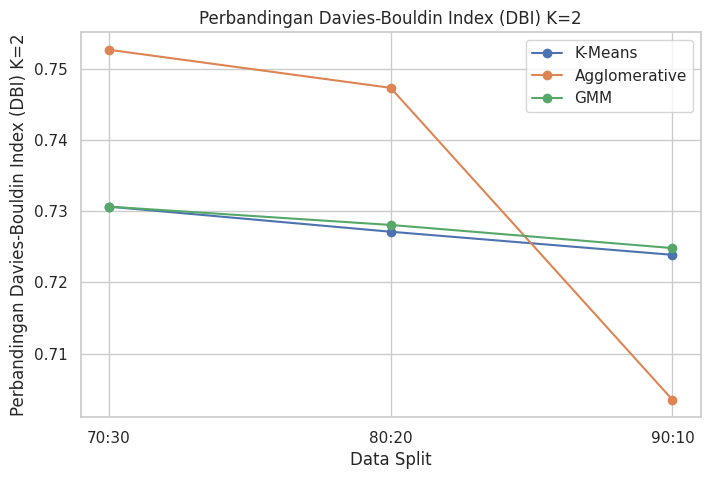

In [131]:
# Reconstruct df_result with DBI columns, assuming 'results' variable is available from Lhu7wmW6hvXR
data = {
    "Split": [r[0] for r in results],
    "K-Means_Silhouette": [r[1] for r in results],
    "K-Means_DBI": [r[2] for r in results],
    "Agglomerative_Silhouette": [r[3] for r in results],
    "Agglomerative_DBI": [r[4] for r in results],
    "GMM_Silhouette": [r[5] for r in results],
    "GMM_DBI": [r[6] for r in results]
}
df_result = pd.DataFrame(data)

plt.figure(figsize=(8,5))

# Plot DBI tiap model
plt.plot(df_result["Split"], df_result["K-Means_DBI"], marker='o', label="K-Means")
plt.plot(df_result["Split"], df_result["Agglomerative_DBI"], marker='o', label="Agglomerative")
plt.plot(df_result["Split"], df_result["GMM_DBI"], marker='o', label="GMM")

# Judul & label
plt.title("Perbandingan Davies-Bouldin Index (DBI) K=2")
plt.xlabel("Data Split")
plt.ylabel("Perbandingan Davies-Bouldin Index (DBI) K=2")

# Tambahan biar rapi
plt.legend()
plt.grid(True)

plt.show()

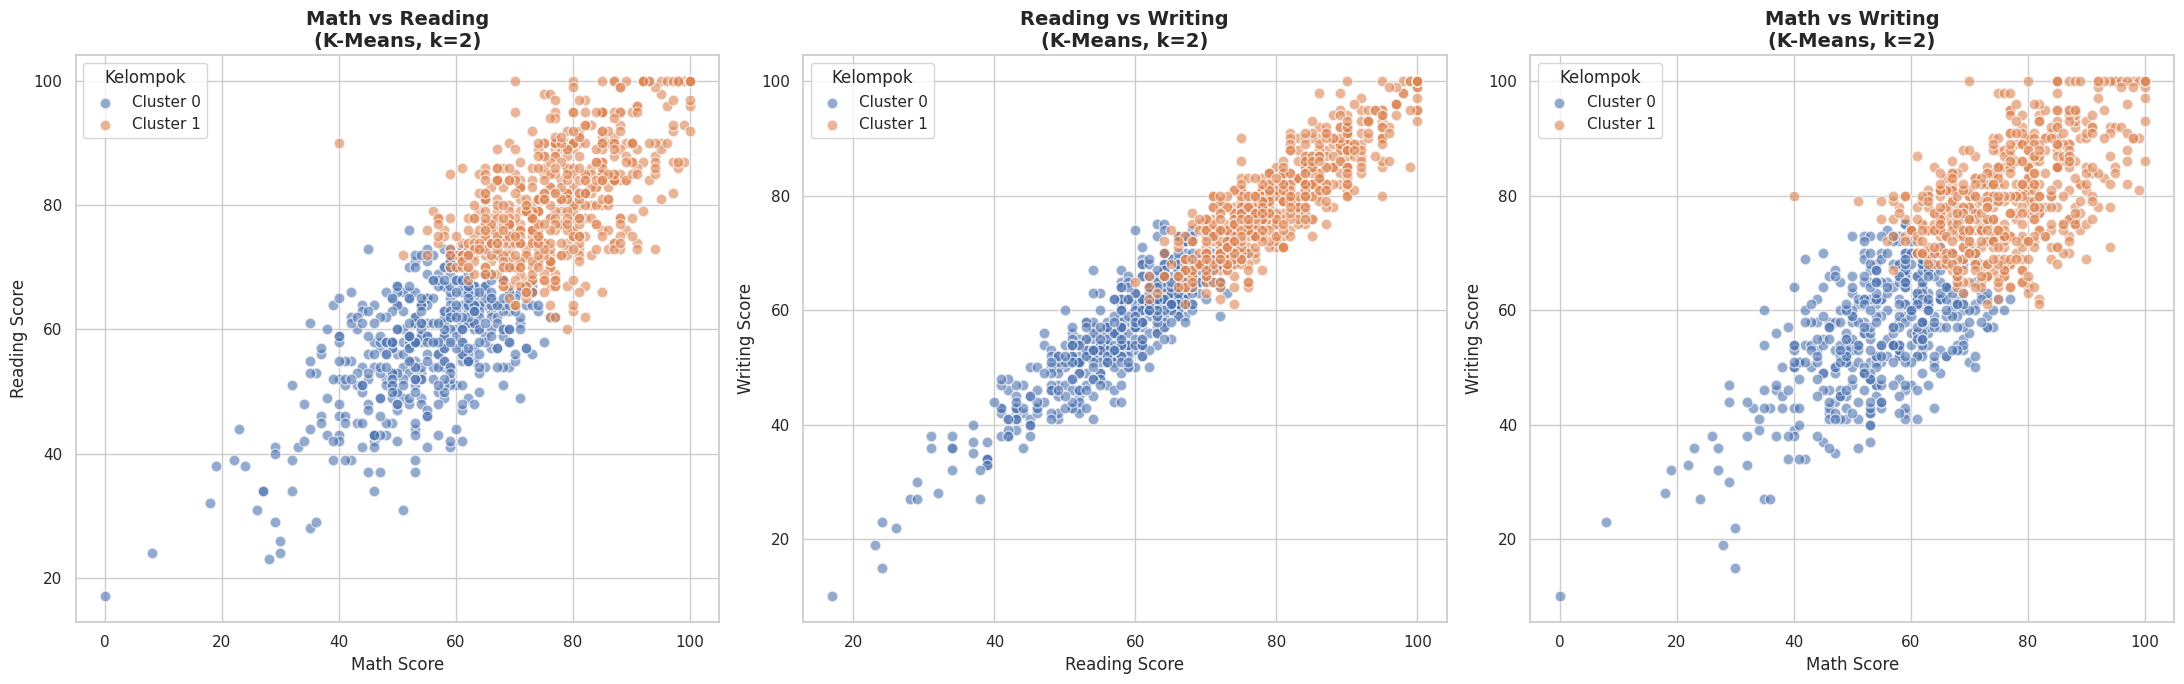

In [132]:
# --- Proses Clustering ---
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_final_scaled)

# --- 1. Inisialisasi Kanvas Utama (1 Baris, 3 Kolom) ---
# figsize diperlebar menjadi 22 agar tidak sesak
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
sns.set_style("whitegrid")

# Konfigurasi data plot agar lebih efisien
plot_targets = [
    {'ax': ax1, 'x': 'math score', 'y': 'reading score', 'title': 'Math vs Reading'},
    {'ax': ax2, 'x': 'reading score', 'y': 'writing score', 'title': 'Reading vs Writing'},
    {'ax': ax3, 'x': 'math score', 'y': 'writing score', 'title': 'Math vs Writing'}
]

# --- 2. Looping untuk Menggambar Ketiga Plot ---
for target in plot_targets:
    for cluster in sorted(df['Cluster'].unique()):
        subset = df[df['Cluster'] == cluster]
        target['ax'].scatter(
            subset[target['x']],
            subset[target['y']],
            label=f"Cluster {cluster}",
            alpha=0.6,
            edgecolors='w',
            s=60
        )

    # Set Label dan Judul secara dinamis
    target['ax'].set_xlabel(target['x'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_ylabel(target['y'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_title(f"{target['title']}\n(K-Means, k=2)", fontsize=14, fontweight='bold')
    target['ax'].legend(title="Kelompok")

# --- Tambahan Akhir biar rapi ---
plt.tight_layout()
plt.show()

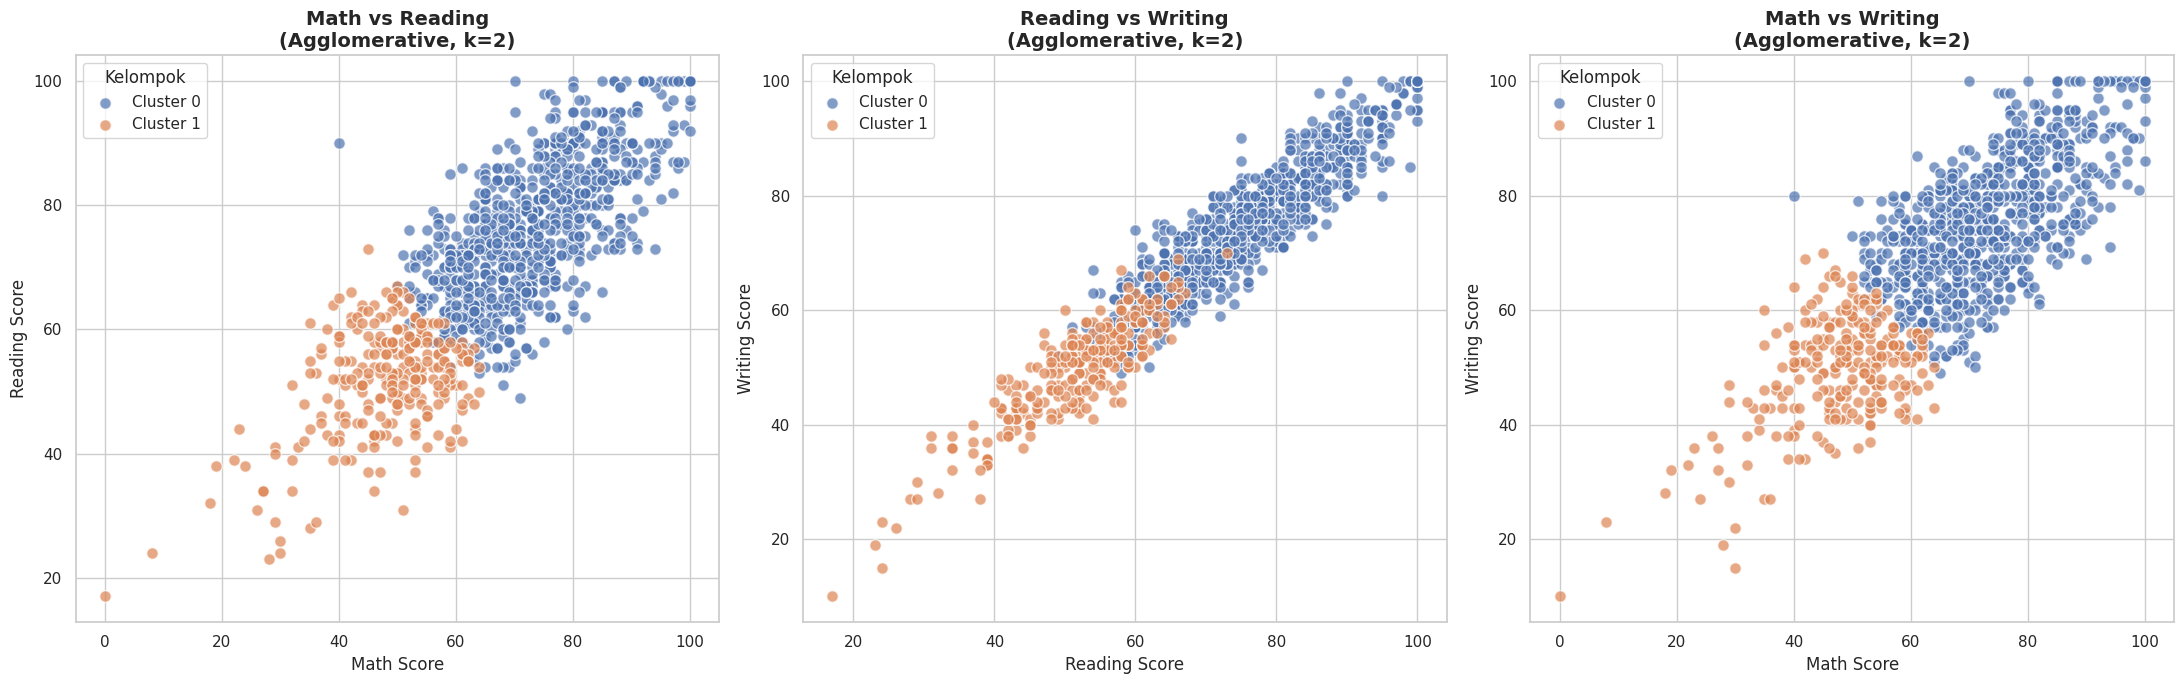

In [133]:
# --- Proses Clustering Menggunakan Model Terbaik ---
# Menggunakan n_clusters=2 dan linkage='ward' sesuai hasil tuning
agglo_final = AgglomerativeClustering(n_clusters=2, linkage='ward')
df['Cluster'] = agglo_final.fit_predict(df_final_scaled)

# --- 1. Inisialisasi Kanvas Utama (1 Baris, 3 Kolom) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
sns.set_style("whitegrid")

# Konfigurasi data plot
plot_targets = [
    {'ax': ax1, 'x': 'math score', 'y': 'reading score', 'title': 'Math vs Reading'},
    {'ax': ax2, 'x': 'reading score', 'y': 'writing score', 'title': 'Reading vs Writing'},
    {'ax': ax3, 'x': 'math score', 'y': 'writing score', 'title': 'Math vs Writing'}
]

# --- 2. Looping untuk Menggambar Ketiga Plot ---
for target in plot_targets:
    # Menggunakan palet warna yang kontras agar mudah dibedakan di PPT
    colors = ['#4C72B0', '#DD8452']
    for i, cluster in enumerate(sorted(df['Cluster'].unique())):
        subset = df[df['Cluster'] == cluster]
        target['ax'].scatter(
            subset[target['x']],
            subset[target['y']],
            label=f"Cluster {cluster}",
            alpha=0.7,
            edgecolors='w',
            s=70,
            c=colors[i]
        )

    # Set Label dan Judul secara dinamis
    target['ax'].set_xlabel(target['x'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_ylabel(target['y'].replace(' score', '').title() + " Score", fontsize=12)
    # Judul diubah menjadi Agglomerative agar sesuai dengan model
    target['ax'].set_title(f"{target['title']}\n(Agglomerative, k=2)", fontsize=14, fontweight='bold')
    target['ax'].legend(title="Kelompok")

# --- Tambahan Akhir agar rapi ---
plt.tight_layout()
plt.show()

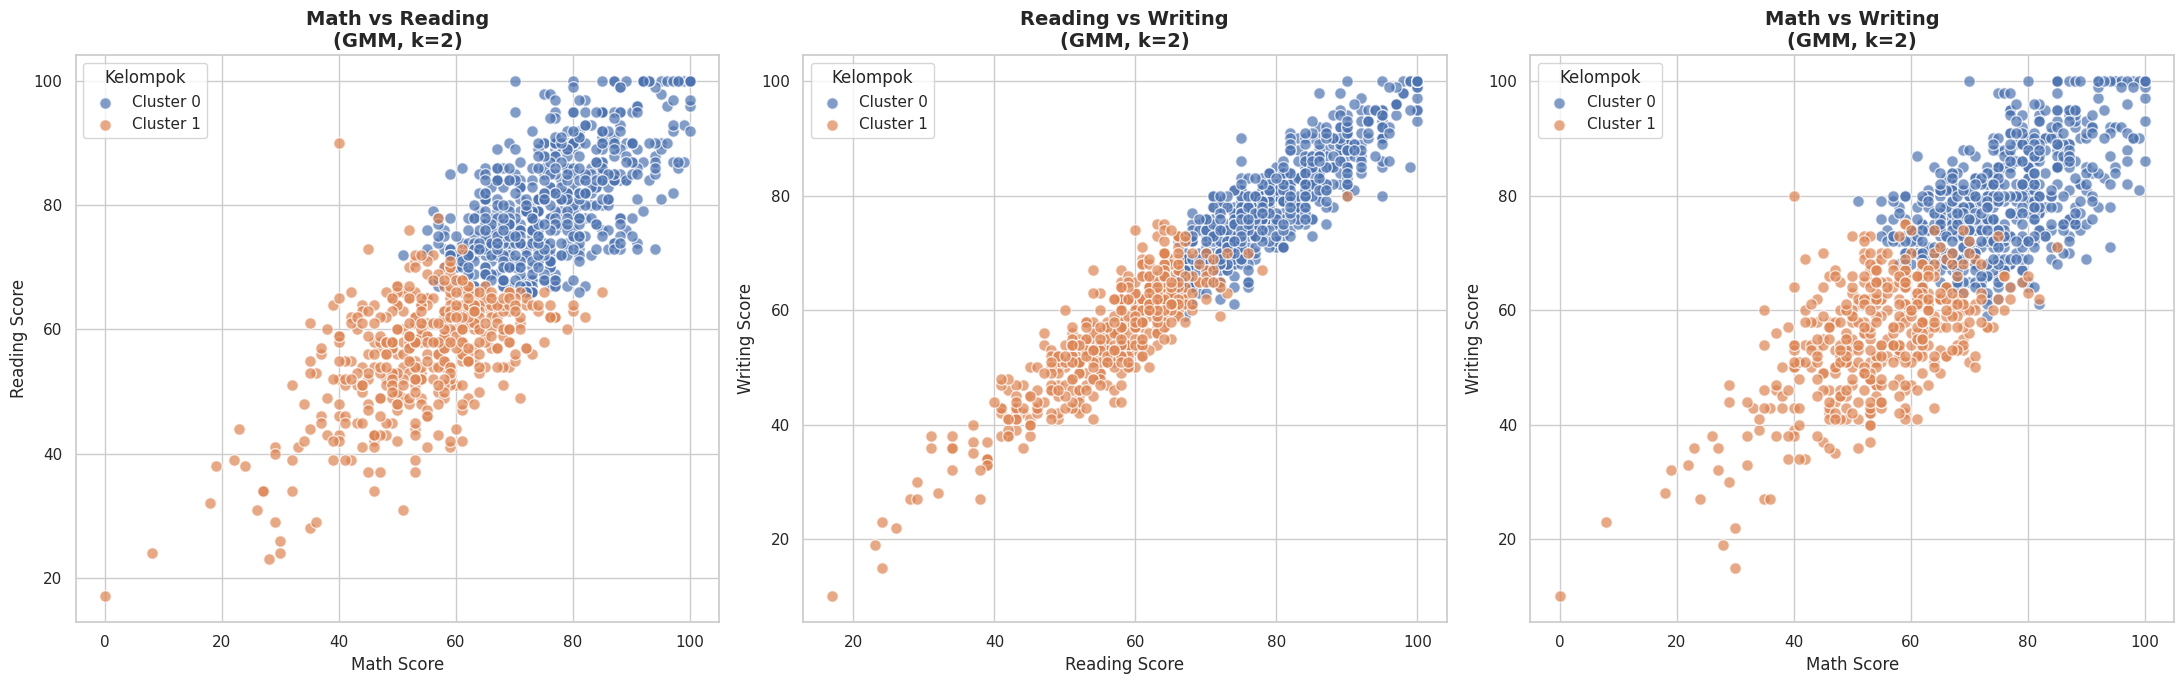

In [134]:
# --- Proses Clustering Menggunakan GMM ---
# Menggunakan n_components=2 (setara dengan n_clusters)
gmm_final = GaussianMixture(n_components=2, random_state=42)
df['Cluster'] = gmm_final.fit_predict(df_final_scaled)

# --- 1. Inisialisasi Kanvas Utama (1 Baris, 3 Kolom) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
sns.set_style("whitegrid")

# Konfigurasi data plot
plot_targets = [
    {'ax': ax1, 'x': 'math score', 'y': 'reading score', 'title': 'Math vs Reading'},
    {'ax': ax2, 'x': 'reading score', 'y': 'writing score', 'title': 'Reading vs Writing'},
    {'ax': ax3, 'x': 'math score', 'y': 'writing score', 'title': 'Math vs Writing'}
]

# --- 2. Looping untuk Menggambar Ketiga Plot ---
for target in plot_targets:
    # Menggunakan palet warna yang konsisten
    colors = ['#4C72B0', '#DD8452']
    for i, cluster in enumerate(sorted(df['Cluster'].unique())):
        subset = df[df['Cluster'] == cluster]
        target['ax'].scatter(
            subset[target['x']],
            subset[target['y']],
            label=f"Cluster {cluster}",
            alpha=0.7,
            edgecolors='w',
            s=70,
            c=colors[i]
        )

    # Set Label dan Judul secara dinamis
    target['ax'].set_xlabel(target['x'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_ylabel(target['y'].replace(' score', '').title() + " Score", fontsize=12)
    # Judul diubah menjadi GMM
    target['ax'].set_title(f"{target['title']}\n(GMM, k=2)", fontsize=14, fontweight='bold')
    target['ax'].legend(title="Kelompok")

# --- Tambahan Akhir agar rapi ---
plt.tight_layout()
plt.show()